In [ ]:
### Note This mnist dataset i can train only 10000 image data my leptop can take alot of time to run the command 

In [37]:
# MNIST Digit Recognition using Machine Learning
# Internship Task - Hassan Ahmad
# Models: Logistic Regression + SVM (optimized)
# Dataset: MNIST (manual from keras)

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import joblib

In [38]:
# -------------------------------
# Step 1: Load Dataset (Manual from Keras)
# -------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

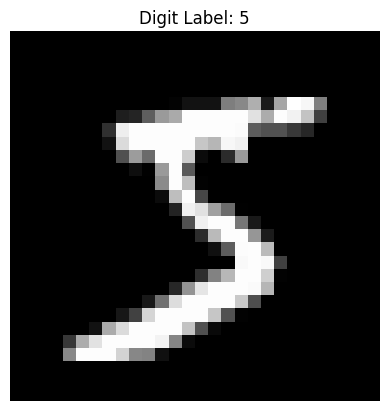

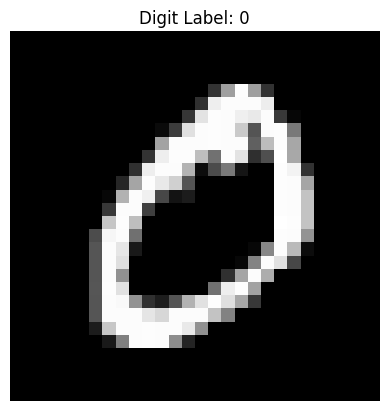

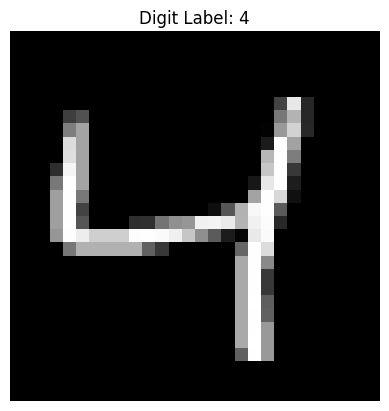

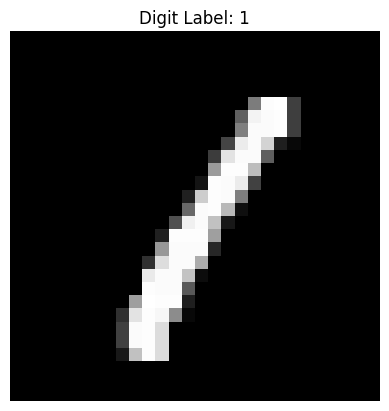

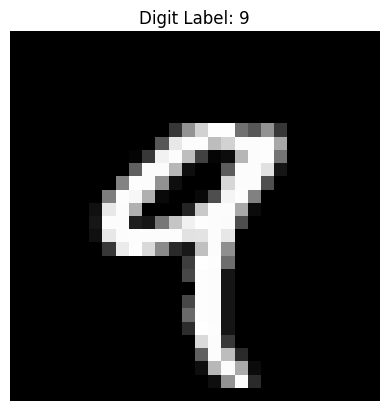

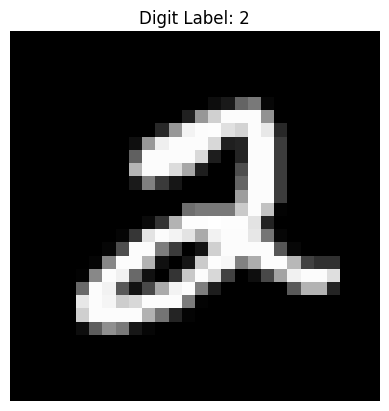

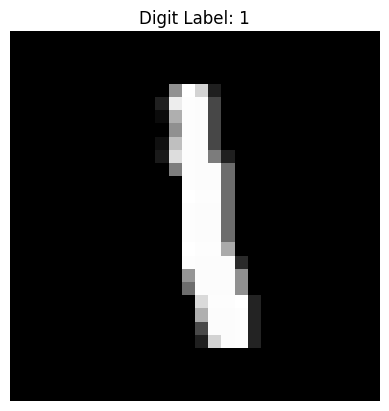

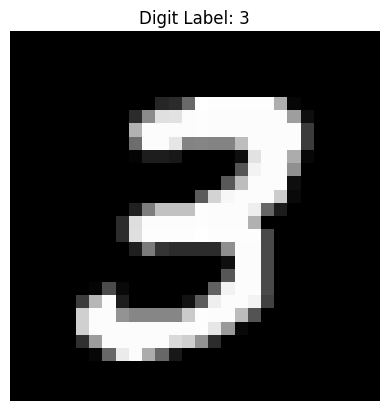

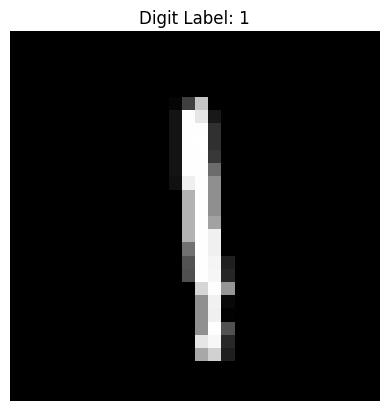

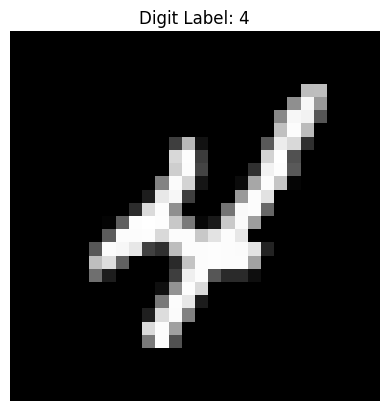

In [39]:
for i in range(10):
    plt.imshow(x_train[i], cmap="gray")        # show image
    plt.title(f"Digit Label: {y_train[i]}")    # actual label
    plt.axis("off")
    plt.show() 

In [40]:
print("Original training data shape:", x_train.shape)  # (60000, 28, 28)

# Step 2: Flatten images (28x28 → 784)
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))
print("After flattening:", x_train.shape)  # (60000, 784)

# Step 3: Convert to float
x_train = x_train.astype(np.float64)
x_test = x_test.astype(np.float64)

# Step 4: Normalize (Option A: Scale 0–255 → 0–1)
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Step 5: Standardize (Option B: zero mean, unit variance) → better for ML
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



Original training data shape: (60000, 28, 28)
After flattening: (60000, 784)


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               100480    
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [28]:
# -------------------------------
# Step 2: Preprocess Data
# -------------------------------
# Flatten 28x28 images → 784 features
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))

# Scale features (important for ML models)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.astype(np.float64))
x_test = scaler.transform(x_test.astype(np.float64))

In [42]:
# -------------------------------
# Step 3: Train Logistic Regression
# -------------------------------
print("\n🔹 Training Logistic Regression...")
log_reg = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    multi_class='multinomial',
    C=2.0
)
log_reg.fit(x_train, y_train)

y_pred_log = log_reg.predict(x_test)
acc_log = metrics.accuracy_score(y_test, y_pred_log)
print("✅ Logistic Regression Accuracy:", acc_log)

# Save Logistic Regression Model
joblib.dump(log_reg, "logistic_model.pkl")
print("💾 Logistic Regression model saved as logistic_model.pkl")




🔹 Training Logistic Regression...


C:\Users\Hassan Ahmad\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression Accuracy: 0.9204
💾 Logistic Regression model saved as logistic_model.pkl


C:\Users\Hassan Ahmad\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
# -------------------------------
# Step 4: Train Optimized SVM (RBF kernel on subset)
# -------------------------------
print("\n🔹 Training SVM with RBF kernel (using subset of 10000 samples)...")

# Use subset of 10,000 for speed
x_train_sub = x_train[:10000]
y_train_sub = y_train[:10000]

svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(x_train_sub, y_train_sub)

y_pred_svm = svm_model.predict(x_test)
acc_svm = metrics.accuracy_score(y_test, y_pred_svm)
print("✅ SVM Accuracy:", acc_svm)

# Save SVM Model
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("💾 SVM model saved as svm_model.pkl")
# Save Scaler





🔹 Training SVM with RBF kernel (using subset of 10000 samples)...
✅ SVM Accuracy: 0.9684
💾 SVM model saved as svm_model.pkl


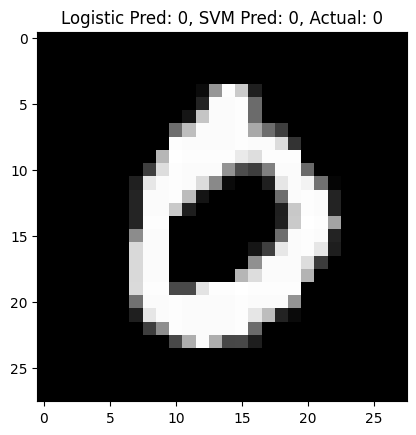

In [85]:
# -------------------------------
# Step 5: Show Prediction Example
# -----------------------------
index = 3
plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Logistic Pred: {y_pred_log[index]}, SVM Pred: {y_pred_svm[index]}, Actual: {y_test[index]}")
plt.show()